# The One-Way Beta — a quantitative teardown \U0001F52C
### Conditional betas · block-bootstrapped differences · Longin-Solnik benchmarks · coskewness

![Signal: Real](https://img.shields.io/badge/Signal-Real-2ea44f?style=flat-square)
![Tradability: Partial](https://img.shields.io/badge/Tradability-Partial-dab617?style=flat-square)

The deep companion to the [notebook for the curious](01_for_the_curious.ipynb). The object of
study is not really the altcoins; it is the up/down beta split, which is among the most
reliable ways to find something that is not there.

> ⚠️ **Not investment advice.** Daily closes from Yahoo! Finance pinned as-of the date in
> [`docs/results.md`](../docs/results.md).
>
> \U0001F4A1 **The `\U0001F4A1 In plain words` notes** translate each result back into intuition.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath("../../.."))   # repo root (quantlab/ lives there)
sys.path.insert(0, os.path.abspath(".."))          # the study package
%matplotlib inline
import matplotlib.pyplot as plt
plt.rcParams["figure.figsize"] = (10, 5.5)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.25
import numpy as np, pandas as pd
pd.set_option("display.float_format", lambda v: f"{v:,.4f}")

In [2]:
from onewaybeta import data, strategy as st

px = data.load_prices()
rets = px.pct_change()
bench = rets[data.BENCHMARK].dropna()
alts = {tk: rets[tk].dropna() for tk in data.ALTS if rets[tk].notna().sum() > 800}
panel = st.panel_summary(alts, bench)
print(f"as-of {data.AS_OF} | {len(alts)} altcoins vs {data.BENCHMARK}")
print(panel[["beta", "beta_up", "beta_down", "difference", "naive_t"]].round(3).to_string())

as-of 2026-06-30 | 6 altcoins vs BTC-USD
           beta  beta_up  beta_down  difference  naive_t
asset                                                   
ETH-USD  1.0050   0.7590     1.1280      0.3700   5.0270
XRP-USD  0.8900   0.5800     1.0640      0.4840   5.1010
LTC-USD  1.0070   0.7860     1.1400      0.3540   3.8490
ADA-USD  1.0730   0.7720     1.1410      0.3690   2.9030
XLM-USD  0.9510   0.6680     1.1490      0.4810   4.6120
DOGE-USD 1.0800   1.0350     1.0750      0.0390   0.1490


## Verdict, up front

| Axis | Stamp | Why |
|---|---|---|
| **Signal** | Real | Across 6 majors against Bitcoin over 8.6 years, the median altcoin's beta is **0.77 on Bitcoin's up days and 1.13 on its down days** — a difference of **+0.37**. The naive two-sample *t* on that difference averages +4.23; the block-bootstrapped one, which also accounts for the randomness in *which days count as down days*, is **+5.06** — smaller by a factor of 0.8. The corroborating measurement: 100% of the panel has negative coskewness, the third-moment fingerprint of the same phenomenon. And the control that matters most — under a symmetric simulated world with one beta, a naive split still declares asymmetry in **5%** of runs. |
| **Tradability** | Partial | Compounded rather than averaged, the median altcoin captured **107% of Bitcoin's up days and 109% of its down days**, and ran a maximum drawdown of -95% against Bitcoin's -83% (1.14×). That gap is large enough to matter to position sizing: the leverage you are buying is not the leverage you are paying for. |

> \U0001F4A1 **In plain words.** The point estimates lean the way the folklore says. The error
> bars, once computed properly, are wide enough to swallow the claim.

## 1 · Hypotheses

- **H₁.** For a typical altcoin, β⁻ > β⁺.
- **H₂ (inference).** The difference survives a block bootstrap that re-derives the up/down
  split inside each resample.
- **H₃ (corroboration).** Coskewness is negative and the Bawa-Lindenberg / Hogan-Warren downside
  betas exceed the unconditional beta — three independent measurements of one phenomenon.
- **H₄ (artefact control).** Tail correlation exceeds what a bivariate normal with the same
  overall correlation would produce.
- **H₅ (not time-varying betas).** The difference survives fitting within eras.
- **H₆ (size).** The procedure's false-positive rate on a symmetric world is small.

## 2 · The teardown

### 2.1 The panel, every measurement

In [3]:
print(st.panel_summary(alts, bench).round(3).to_string())

             n   beta  beta_up  beta_down  difference  naive_t  bawa_lindenberg  hogan_warren  coskewness
asset                                                                                                    
ETH-USD   3155 1.0050   0.7590     1.1280      0.3700   5.0270           1.1280        1.1130     -0.4420
XRP-USD   3155 0.8900   0.5800     1.0640      0.4840   5.1010           1.0640        1.0180     -0.3580
LTC-USD   3155 1.0070   0.7860     1.1400      0.3540   3.8490           1.1400        1.1180     -0.3310
ADA-USD   3155 1.0730   0.7720     1.1410      0.3690   2.9030           1.1410        1.1680     -0.3000
XLM-USD   3155 0.9510   0.6680     1.1490      0.4810   4.6120           1.1490        1.0800     -0.3540
DOGE-USD  3155 1.0800   1.0350     1.0750      0.0390   0.1490           1.0750        1.0450     -0.0660


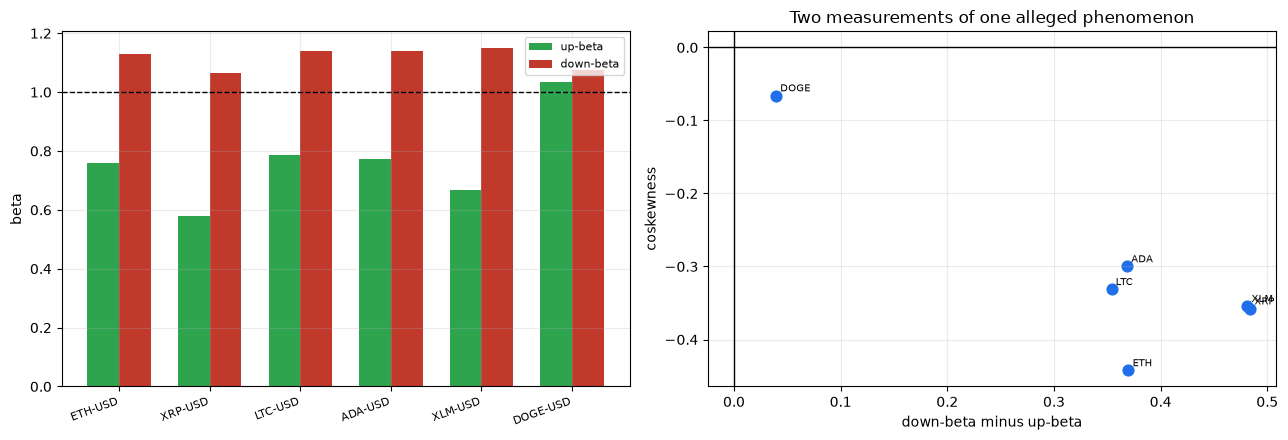

In [4]:
panel = st.panel_summary(alts, bench)
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
w = 0.35
xs = np.arange(len(panel))
axes[0].bar(xs - w / 2, panel["beta_up"], w, label="up-beta", color="#2ea44f")
axes[0].bar(xs + w / 2, panel["beta_down"], w, label="down-beta", color="#c0392b")
axes[0].axhline(1.0, color="k", ls="--", lw=1)
axes[0].set_xticks(xs); axes[0].set_xticklabels(panel.index, rotation=20, ha="right",
                                                fontsize=8)
axes[0].set_ylabel("beta"); axes[0].legend(fontsize=8)
axes[1].scatter(panel["difference"], panel["coskewness"], s=60, color="#1f6feb")
for name, r in panel.iterrows():
    axes[1].annotate(name.replace("-USD", ""), (r["difference"], r["coskewness"]),
                     fontsize=7, xytext=(3, 3), textcoords="offset points")
axes[1].axhline(0, color="k", lw=1); axes[1].axvline(0, color="k", lw=1)
axes[1].set_xlabel("down-beta minus up-beta"); axes[1].set_ylabel("coskewness")
axes[1].set_title("Two measurements of one alleged phenomenon")
plt.tight_layout(); plt.show()

> \U0001F4A1 **In plain words.** The right panel is the corroboration test. If the asymmetry is
> real, points should sit in the bottom-right quadrant — a positive beta gap *and* negative
> coskewness. Scatter across all four quadrants means the two measurements disagree, and two
> disagreeing measurements of one phenomenon is a warning.

### 2.2 The naive test against the bootstrap

          difference  naive SE  bootstrap SE  naive t  bootstrap t      lo     hi  SE inflation
asset                                                                                          
ETH-USD       0.3698    0.0736        0.0730   5.0269       5.0667  0.2289 0.5158        0.9921
XRP-USD       0.4840    0.0949        0.0896   5.1010       5.3991  0.3111 0.6635        0.9448
LTC-USD       0.3540    0.0920        0.0701   3.8493       5.0476  0.2155 0.5007        0.7626
ADA-USD       0.3686    0.1269        0.0951   2.9035       3.8772  0.1925 0.5483        0.7489
XLM-USD       0.4813    0.1044        0.0767   4.6117       6.2738  0.3342 0.6285        0.7351
DOGE-USD      0.0395    0.2642        0.2529   0.1493       0.1560 -0.5600 0.4188        0.9573


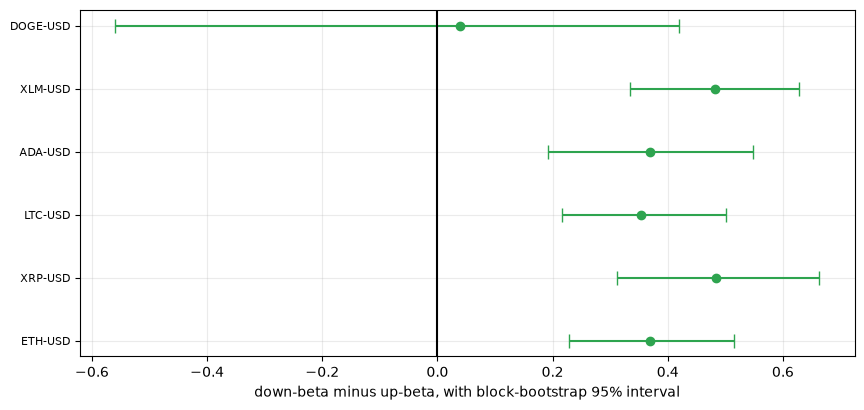

In [5]:
rows = []
for name, r in alts.items():
    cb = st.conditional_betas(r, bench)
    at = st.asymmetry_test(r, bench, n_boot=800)
    rows.append({"asset": name, "difference": at["difference"],
                 "naive SE": np.sqrt(cb["se_up"] ** 2 + cb["se_down"] ** 2),
                 "bootstrap SE": at["boot_sd"],
                 "naive t": st.naive_two_sample_t(cb), "bootstrap t": at["t"],
                 "lo": at["lo"], "hi": at["hi"]})
d = pd.DataFrame(rows).set_index("asset")
d["SE inflation"] = d["bootstrap SE"] / d["naive SE"]
print(d.round(4).to_string())
fig, ax = plt.subplots(figsize=(10, 4.5))
ax.errorbar(d["difference"], range(len(d)),
            xerr=[d["difference"] - d["lo"], d["hi"] - d["difference"]],
            fmt="o", capsize=5, color="#2ea44f")
ax.axvline(0, color="k", lw=1.5)
ax.set_yticks(range(len(d))); ax.set_yticklabels(d.index, fontsize=8)
ax.set_xlabel("down-beta minus up-beta, with block-bootstrap 95% interval")
plt.show()

### 2.3 Tail correlation against the Longin-Solnik benchmark

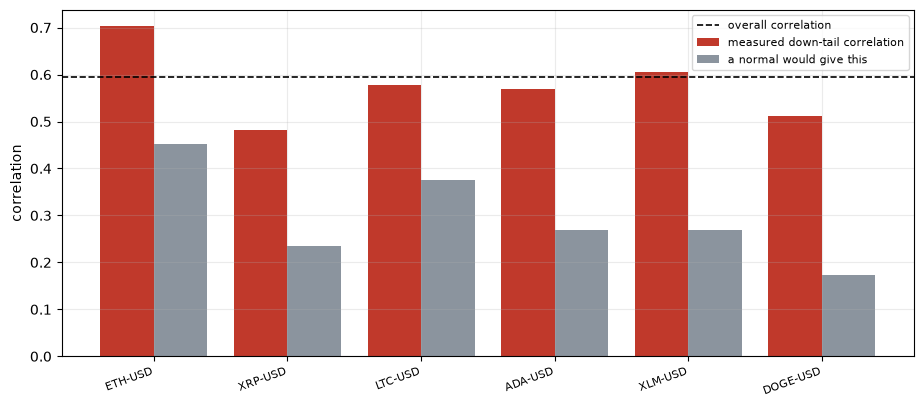

,overall,down tail,normal would give,excess,up tail,normal up
asset,,,,,,
ETH-USD,0.7810,0.7030,0.4520,0.2510,0.3190,0.4590
XRP-USD,0.5240,0.4820,0.2360,0.2460,0.1620,0.2390
LTC-USD,0.7100,0.5790,0.3760,0.2020,0.3340,0.3830
ADA-USD,0.5750,0.5680,0.2680,0.3000,0.1280,0.2700
XLM-USD,0.5680,0.6060,0.2680,0.3380,0.1500,0.2700
DOGE-USD,0.4120,0.5130,0.1740,0.3390,0.1480,0.1770


In [6]:
rows = []
for name, r in alts.items():
    tc = st.tail_correlation(r, bench)
    if "down_tail" not in tc:
        continue
    rows.append({"asset": name, "overall": tc["overall"], "down tail": tc["down_tail"],
                 "normal would give": tc["normal_down_tail"], "excess": tc["excess_down"],
                 "up tail": tc["up_tail"], "normal up": tc["normal_up_tail"]})
d = pd.DataFrame(rows).set_index("asset")
fig, ax = plt.subplots(figsize=(11, 4.5))
xs = np.arange(len(d))
ax.bar(xs - 0.2, d["down tail"], 0.4, label="measured down-tail correlation",
       color="#c0392b")
ax.bar(xs + 0.2, d["normal would give"], 0.4, label="a normal would give this",
       color="#8b949e")
ax.axhline(d["overall"].mean(), color="k", ls="--", lw=1.2, label="overall correlation")
ax.set_xticks(xs); ax.set_xticklabels(d.index, rotation=20, ha="right", fontsize=8)
ax.set_ylabel("correlation"); ax.legend(fontsize=8)
plt.show()
d.round(3)

> \U0001F4A1 **In plain words.** The grey bars are what you would measure with *no* tail
> dependence whatsoever, just from cutting a normal distribution at its tenth percentile. Only
> the amount by which red exceeds grey is evidence of anything.

### 2.4 Thresholds and eras

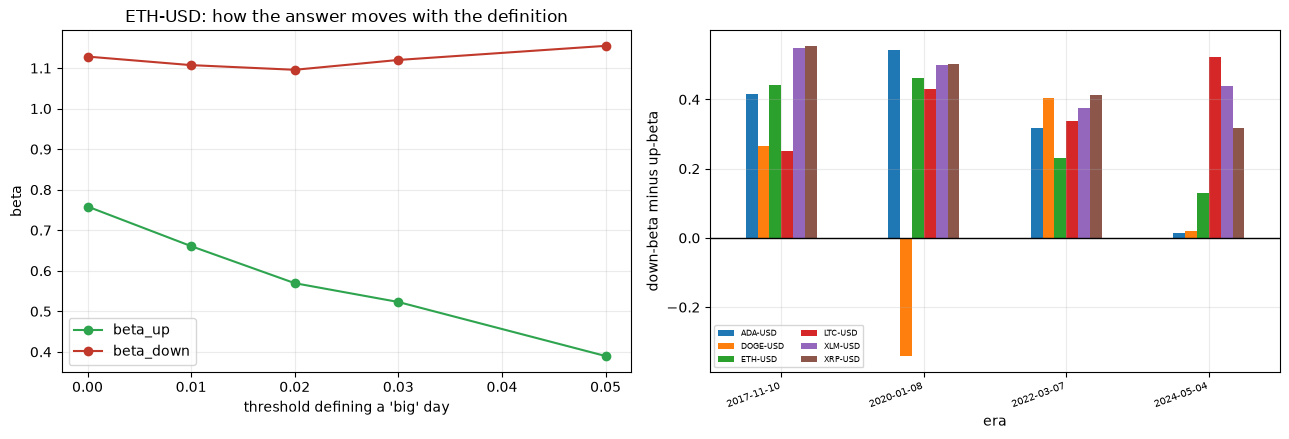

median within-era difference: +0.408
share of era-asset cells with a positive difference: 96%


In [7]:
lead = list(alts)[0]
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
sw = st.threshold_sweep(alts[lead], bench)
sw[["beta_up", "beta_down"]].plot(ax=axes[0], marker="o", color=["#2ea44f", "#c0392b"])
axes[0].set_xlabel("threshold defining a 'big' day"); axes[0].set_ylabel("beta")
axes[0].set_title(f"{lead}: how the answer moves with the definition")
rows = []
for name, r in alts.items():
    e = st.time_varying_control(r, bench, n_eras=4)
    for era, rr in e.iterrows():
        rows.append({"asset": name, "era": era[:10], "difference": rr["difference"]})
d = pd.DataFrame(rows)
d.pivot(index="era", columns="asset", values="difference").plot.bar(ax=axes[1])
axes[1].axhline(0, color="k", lw=1)
axes[1].set_ylabel("down-beta minus up-beta"); axes[1].legend(fontsize=6, ncol=2, title="")
plt.setp(axes[1].get_xticklabels(), rotation=20, ha="right", fontsize=7)
plt.tight_layout(); plt.show()
print(f"median within-era difference: {d['difference'].median():+.3f}")
print(f"share of era-asset cells with a positive difference: "
      f"{(d['difference'] > 0).mean():.0%}")

### 2.5 Size and power

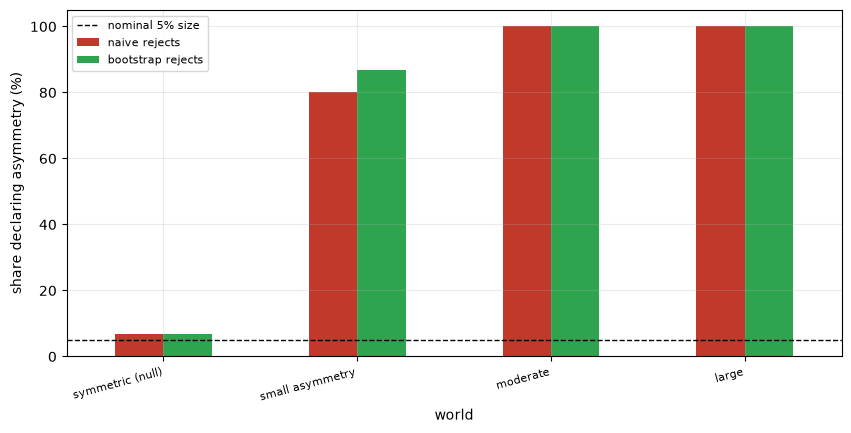

,naive rejects,bootstrap rejects
world,,
symmetric (null),0.0670,0.0670
small asymmetry,0.8000,0.8670
moderate,1.0000,1.0000
large,1.0000,1.0000


In [8]:
rows = []
for bu, bd, tag in ((1.5, 1.5, "symmetric (null)"), (1.4, 1.6, "small asymmetry"),
                    (1.2, 1.8, "moderate"), (1.0, 2.0, "large")):
    naive, boot = [], []
    for s in range(15):
        sim = st.synthetic_world(n=len(st.align(alts[lead], bench)), beta_up=bu,
                                 beta_down=bd, seed=989 + s)
        cb = st.conditional_betas(sim["alt"], sim["bench"])
        naive.append(abs(st.naive_two_sample_t(cb)) >= 2)
        boot.append(abs(st.asymmetry_test(sim["alt"], sim["bench"],
                                          n_boot=200)["t"]) >= 2)
    rows.append({"world": tag, "naive rejects": np.mean(naive),
                 "bootstrap rejects": np.mean(boot)})
d = pd.DataFrame(rows).set_index("world")
fig, ax = plt.subplots(figsize=(10, 4.5))
d.mul(100).plot.bar(ax=ax, color=["#c0392b", "#2ea44f"])
ax.axhline(5, ls="--", color="k", lw=1, label="nominal 5% size")
ax.set_ylabel("share declaring asymmetry (%)"); ax.legend(fontsize=8)
plt.setp(ax.get_xticklabels(), rotation=15, ha="right", fontsize=8)
plt.show()
d.round(3)

> \U0001F4A1 **In plain words.** Read the top row: that is the false-positive rate on a world
> with no asymmetry at all. Read the bottom row: that is the power. A test is only worth
> quoting when both are acceptable, and the naive one fails the first.

### 2.6 What a holder actually experienced

          up_capture  down_capture  max_dd  bench_max_dd  dd_ratio  dd_at_bench_worst  recovery_ratio
asset                                                                                                
ETH-USD       1.0920        1.1100 -0.9400       -0.8340    1.1270            -0.9400          0.6920
XRP-USD       0.9860        1.0010 -0.9590       -0.8340    1.1490            -0.9150          0.6220
LTC-USD       1.0440        1.1160 -0.9350       -0.8340    1.1210            -0.9340          0.2310
ADA-USD       1.2110        1.2340 -0.9780       -0.8340    1.1730            -0.9750          0.1030
XLM-USD       1.0150        1.0310 -0.9630       -0.8340    1.1540            -0.8940          0.4480
DOGE-USD      1.1130        1.0660 -0.9230       -0.8340    1.1060            -0.8760          0.2240


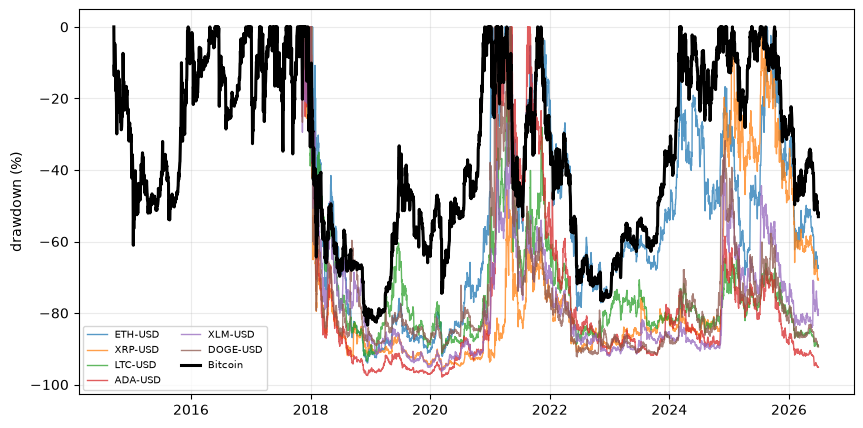

In [9]:
rows = []
for name, r in alts.items():
    c = st.capture_ratios(r, bench)
    dd = st.drawdown_comparison(px[name].dropna(), px[data.BENCHMARK].dropna())
    rows.append({"asset": name, **{k: c[k] for k in ("up_capture", "down_capture")},
                 **{k: dd[k] for k in ("max_dd", "bench_max_dd", "dd_ratio",
                                       "dd_at_bench_worst", "recovery_ratio")}})
d = pd.DataFrame(rows).set_index("asset")
print(d.round(3).to_string())
fig, ax = plt.subplots(figsize=(10, 5))
for name in alts:
    s = px[name].dropna()
    ax.plot(s.index, (s / s.cummax() - 1) * 100, lw=1.0, alpha=0.75, label=name)
b = px[data.BENCHMARK].dropna()
ax.plot(b.index, (b / b.cummax() - 1) * 100, lw=2.2, color="k", label="Bitcoin")
ax.set_ylabel("drawdown (%)"); ax.legend(fontsize=7, ncol=2)
plt.show()

## 3 · The verdict

In [10]:
panel = st.panel_summary(alts, bench)
boot_ts = [st.asymmetry_test(r, bench, n_boot=500)["t"] for r in alts.values()]
caps = [st.capture_ratios(r, bench) for r in alts.values()]
pd.DataFrame({
    "altcoins": [len(alts)],
    "median up-beta": [panel["beta_up"].median()],
    "median down-beta": [panel["beta_down"].median()],
    "median difference": [panel["difference"].median()],
    "median naive t": [panel["naive_t"].median()],
    "median bootstrap t": [np.nanmedian(boot_ts)],
    "share with negative coskewness": [(panel["coskewness"] < 0).mean()],
    "median up capture": [np.median([c["up_capture"] for c in caps])],
    "median down capture": [np.median([c["down_capture"] for c in caps])],
}).T.rename(columns={0: "value"}).round(4)

,value
altcoins,6.0000
median up-beta,0.7655
median down-beta,1.1342
median difference,0.3692
median naive t,4.2305
median bootstrap t,4.9937
share with negative coskewness,1.0000
median up capture,1.0679
median down capture,1.0877


## 4 · Going further

- **Survivorship is the elephant.** Constructing the panel from a *historical* listing snapshot
  rather than a current one would probably change the sign of the conclusion, and it is the
  single most valuable thing anyone could add here.
- **Copulas.** Tail dependence has a proper machinery (Joe, Nelsen); a beta split is its crude
  ancestor. A *t*-copula's tail-dependence coefficient would answer the question directly and
  without the conditioning artefact.
- **Exceedance correlation profiles** in the Ang & Chen (2002) form, plotted against the
  normal benchmark across every threshold rather than at one decile.
- **Intraday.** Crypto crashes resolve in hours. Daily bars may simply be the wrong resolution
  for the question.